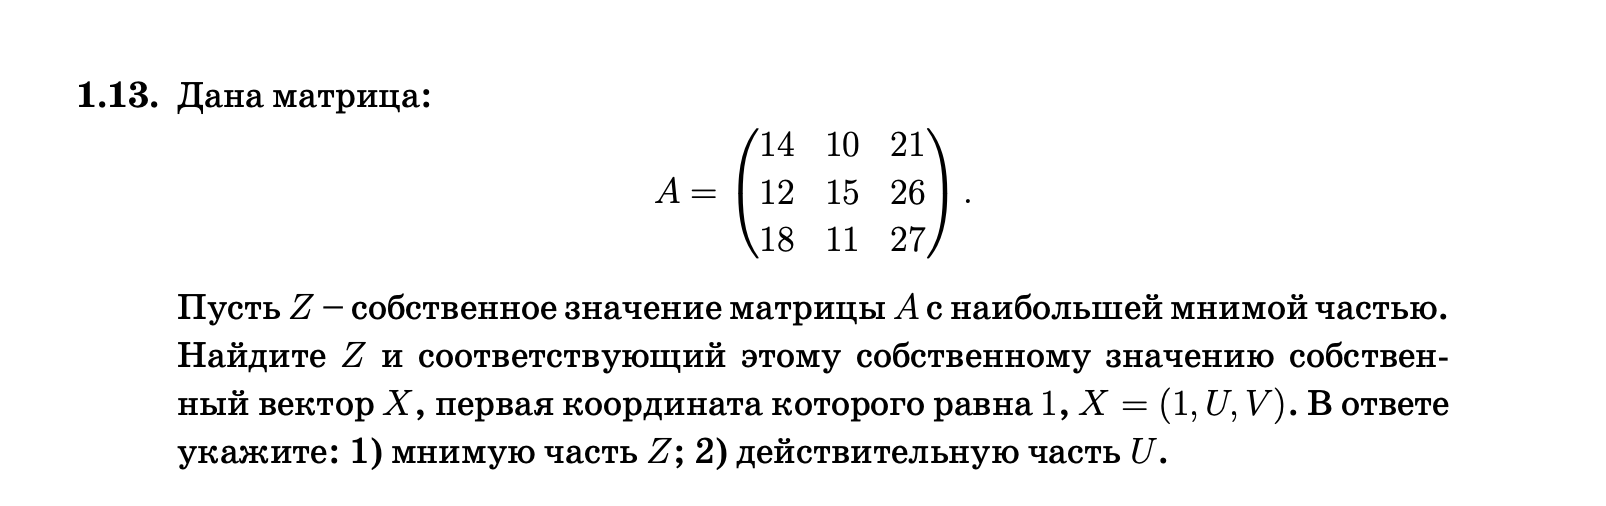


---

## Основные определения

### Собственное значение

Число $\lambda$ называется **собственным значением** квадратной матрицы $A$, если существует ненулевой вектор $X$, для которого

$$
AX=\lambda X.
$$

То есть при умножении собственного вектора на матрицу результат отличается от исходного вектора только умножением на число $\lambda$.

### Собственный вектор

Ненулевой вектор $X$, удовлетворяющий равенству

$$
AX=\lambda X,
$$

называется **собственным вектором**, соответствующим собственному значению $\lambda$.

Одному собственному значению соответствует не единственный вектор: если $X$ — собственный вектор, то $cX$, где $c\neq0$, также является собственным вектором.

### Комплексное число

Комплексное число имеет вид

$$
z=a+bi,
$$

где:

- $a=\operatorname{Re}(z)$ — действительная часть;
- $b=\operatorname{Im}(z)$ — мнимая часть;
- $i$ — мнимая единица, $i^2=-1$.

Если матрица вещественная, её комплексные собственные значения возникают сопряжёнными парами:

$$
a+bi,\qquad a-bi.
$$

### Нормировка собственного вектора

Так как собственный вектор можно умножать на любое ненулевое число, его можно привести к удобному виду.

Если

$$
X=
\begin{pmatrix}
x_1\\x_2\\x_3
\end{pmatrix},
\qquad x_1\neq0,
$$

то разделим все координаты на $x_1$:

$$
\frac{X}{x_1}=
\begin{pmatrix}
1\\
x_2/x_1\\
x_3/x_1
\end{pmatrix}
=
\begin{pmatrix}
1\\U\\V
\end{pmatrix}.
$$

Именно такая нормировка требуется в условии задачи.

---

## Необходимые формулы

### 1. Уравнение для собственного значения и собственного вектора

$$
AX=\lambda X.
$$

Эквивалентная форма:

$$
(A-\lambda I)X=0.
$$

Ненулевое решение существует, когда

$$
\det(A-\lambda I)=0.
$$

Это уравнение называется характеристическим уравнением матрицы.

### 2. Действительная и мнимая части

Для

$$
z=a+bi
$$

имеем

$$
\operatorname{Re}(z)=a,\qquad
\operatorname{Im}(z)=b.
$$

В NumPy эти части доступны как `.real` и `.imag`.

### 3. Проверка найденного собственного вектора

После вычислений результат можно проверить непосредственно по определению:

$$
AX=ZX.
$$

---

## Алгоритм решения

### Шаг 1: Задаём исходную матрицу

Из условия

$$
A=
\begin{pmatrix}
14&10&21\\
12&15&26\\
18&11&27
\end{pmatrix}.
$$

В программе создаём её как двумерный массив NumPy.

### Шаг 2: Находим собственные значения и собственные векторы

Для вычисления используем функцию `np.linalg.eig(A)`.

Она возвращает:

1. массив собственных значений;
2. матрицу собственных векторов.

Важно, что собственные векторы располагаются **по столбцам**. Если `eigenvalues[i]` — некоторое собственное значение, то соответствующий ему собственный вектор находится в `eigenvectors[:, i]`.

Для данной матрицы получаются одно вещественное собственное значение и два комплексно-сопряжённых.

### Шаг 3: Выбираем собственное значение $Z$

По условию требуется не самое большое собственное значение, а значение с **наибольшей мнимой частью**.

Поэтому для каждого найденного $\lambda_i$ рассматриваем

$$
\operatorname{Im}(\lambda_i)
$$

и выбираем максимальное значение.

В программе `eigenvalues.imag` получает массив мнимых частей, а `np.argmax` возвращает индекс максимального элемента.

После этого

$$
Z=\text{eigenvalues[index]}.
$$

### Шаг 4: Выбираем соответствующий собственный вектор

Нельзя независимо выбирать любой собственный вектор. Необходимо взять вектор, соответствующий именно найденному $Z$.

Поэтому используем тот же индекс:

`eigenvectors[:, index]`.

Пусть полученный вектор равен

$$
X_0=(x_1,x_2,x_3).
$$

### Шаг 5: Приводим вектор к виду $X=(1,U,V)$

По условию первая координата должна быть равна $1$.

Так как $x_1\neq0$, делим весь собственный вектор на первую координату:

$$
X=\frac{X_0}{x_1}
=
\left(
1,\frac{x_2}{x_1},\frac{x_3}{x_1}
\right).
$$

Тогда

$$
U=\frac{x_2}{x_1},\qquad
V=\frac{x_3}{x_1}.
$$

### Шаг 6: Получаем требуемые части ответа

Из найденного собственного значения берём

$$
\operatorname{Im}(Z),
$$

а из второй координаты нормированного собственного вектора —

$$
\operatorname{Re}(U).
$$

### Шаг 7: Проверяем результат

Для найденных $Z$ и $X$ проверяем

$$
AX=ZX.
$$

При вычислениях с числами с плавающей точкой возможна очень небольшая погрешность, поэтому в программе используется `np.allclose`, а не точное сравнение через `==`.


In [2]:
import numpy as np

# Исходная матрица A
A = np.array([
    [14, 10, 21],
    [12, 15, 26],
    [18, 11, 27]
], dtype=float)

# Находим собственные значения и соответствующие собственные векторы
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Собственные значения:")
print(eigenvalues)

# Получаем мнимые части всех собственных значений
imaginary_parts = eigenvalues.imag

# Находим индекс собственного значения с наибольшей мнимой частью
index = np.argmax(imaginary_parts)

# Выбираем искомое собственное значение Z
Z = eigenvalues[index]

# Берём соответствующий ему собственный вектор:
# собственные векторы в результате np.linalg.eig расположены по столбцам
X = eigenvectors[:, index]

# Нормируем собственный вектор так,
# чтобы его первая координата стала равна 1
X = X / X[0]

# После нормировки X имеет вид (1, U, V)
U = X[1]
V = X[2]

# Проверяем определение собственного вектора: A*X = Z*X
check = np.allclose(A @ X, Z * X)

# Выводим найденные величины
print("\nZ =", Z)
print("X =", X)
print("U =", U)
print("V =", V)
print("\nПроверка A @ X = Z * X:", check)

# Требуемый ответ
print(f"\n1) Im(Z) = {Z.imag:.9f}")
print(f"2) Re(U) = {U.real:.9f}")


Собственные значения:
[52.06231934+0.j          1.96884033+0.34478935j  1.96884033-0.34478935j]

Z = (1.9688403308016502+0.3447893484271669j)
X = [ 1.        -0.j          3.74781973+1.33084677j -2.35758843-0.61731802j]
U = (3.747819729394814+1.3308467741437155j)
V = (-2.3575884268164997-0.6173180187147613j)

Проверка A @ X = Z * X: True

1) Im(Z) = 0.344789348
2) Re(U) = 3.747819729
